## Question 2
### **Bright Stars Around M67 with ADQL**

In [19]:
# Import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from astroquery.gaia import Gaia

*A colleague is interested in the open cluster Messier 67 (RA = 132.825 deg, Dec = 11.8
deg) and is considering an observation proposal using the 2dF fibre positioner and HERMES
spectrograph (effective for Gaia G < 14) to follow up stars observed with the APOGEE
spectrograph, for which they only have 2MASS catalogue identifiers.*

1.

*Write an ADQL query that returns all stars in the Gaia DR3 gaiadr3.gaia source
table within 1 degree of M67 with G < 14 (phot_g_mean_mag) and crossmatches them
with 2MASS (gaiadr1.tmass_original_valid). You can execute the query on the Gaia
archive website or via astroquery. Include your ADQL query in the notebook and
report the number of returned stars.*

In [2]:
galah_data = Table.read('data/galah_dr3_allstar_m67_lite.csv')
galah_data['source_id'] = np.array([np.int64(x) for x in galah_data['dr3_source_id']])
gaia_source_ids = galah_data['source_id'].tolist()
gaia_source_ids_table = Table([gaia_source_ids], names=['source_id'])

In [5]:
query=f"""
SELECT *
FROM gaiadr3.gaia_source AS gaia
JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS xmatch USING (source_id)
JOIN gaiadr3.tmass_psc_xsc_join AS xjoin USING (clean_tmass_psc_xsc_oid)
JOIN gaiadr1.tmass_original_valid AS tmass ON xjoin.original_psc_source_id = tmass.designation
WHERE 1 = CONTAINS(POINT(132.825, 11.8), CIRCLE(gaia.ra, gaia.dec, 1.0))
AND gaia.phot_g_mean_mag < 14
"""

#job = Gaia.launch_job_async(query=query)
job = Gaia.launch_job_async(query=query, upload_resource=gaia_source_ids_table, upload_table_name="t1")
gaiadr3_match = job.get_results()

INFO: Query finished. [astroquery.utils.tap.core]


In [21]:
n_stars = len(gaiadr3_match)
print(f"Number of stars in the Gaia DR3 crossmatch: {n_stars}")

1256801741.py: Number of stars in the Gaia DR3 crossmatch: 1018


2.

*Identify stars with:*

-*bad 2MASS photometry (ph_qual is not ’AAA’);*

-*non-positive values of Gaia parallax.*

*Apply these quality cuts and report how many stars remain.*

In [7]:
query2 = f"""
SELECT *
FROM gaiadr3.gaia_source AS gaia
JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS xmatch USING (source_id)
JOIN gaiadr3.tmass_psc_xsc_join AS xjoin USING (clean_tmass_psc_xsc_oid)
JOIN gaiadr1.tmass_original_valid AS tmass ON xjoin.original_psc_source_id = tmass.designation
WHERE 1 = CONTAINS(POINT(132.825, 11.8), CIRCLE(gaia.ra, gaia.dec, 1.0))
AND gaia.phot_g_mean_mag < 14
AND tmass.ph_qual = 'AAA'
AND gaia.parallax > 0
"""

#job2 = Gaia.launch_job_async(query=query2)
job2 = Gaia.launch_job_async(query=query2, upload_resource=gaia_source_ids_table, upload_table_name="t1")
gaiadr3_match2 = job2.get_results()

INFO: Query finished. [astroquery.utils.tap.core]


In [22]:
n_stars2 = len(gaiadr3_match2)
print(f"Number of stars after quality cuts: {n_stars2}")

509950021.py: Number of stars after quality cuts: 988


3.

*Create and save a two-panel figure showing:*

*• Gaia BP−RP versus absolute G magnitude, using bp_rp;*

*• 2MASS J−Ks versus apparent H magnitude, using j_m, h_m, and ks_m*

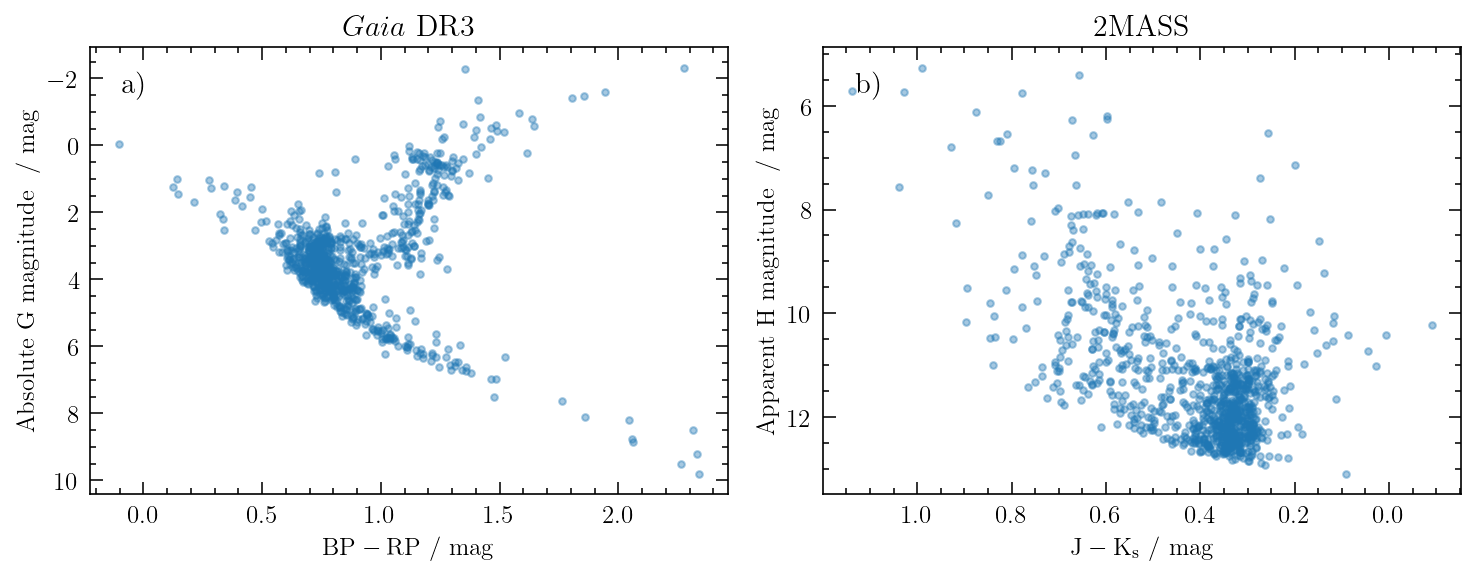

In [23]:
data = gaiadr3_match2

f, gs = plt.subplots(1, 2, figsize=(10,4))

# Left panel (Gaia BP-RP)
ax = gs[0]
ax.text(0.05, 0.95, 'a)', transform=ax.transAxes, fontsize=14, ha = 'left', va='top')

sc = ax.scatter(
    data['bp_rp'],
    data['phot_g_mean_mag'] + 5 * np.log10(data['parallax']/100.),
    s=10,
    alpha=0.4
)
ax.invert_yaxis()
ax.set_ylabel(r'Absolute G magnitude $~/~\mathrm{mag}$')
ax.set_xlabel(r'$\mathrm{BP - RP} ~/~\mathrm{mag}$')
ax.set_title(r'$Gaia$ DR3')

# Right panel (2MASS J-Ks)
ax = gs[1]
ax.text(0.05, 0.95, 'b)', transform=ax.transAxes, fontsize=14, ha = 'left', va='top')
sc2 = ax.scatter(
    data['j_m'] - data['ks_m'],
    data['h_m'], 
    s=10,
    alpha=0.4
)
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_ylabel(r'Apparent H magnitude $~/~\mathrm{mag}$')
ax.set_xlabel(r'$\mathrm{J - K_s} ~/~\mathrm{mag}$')
ax.set_title('2MASS')

plt.tight_layout()
plt.savefig('figures/question2_cmds.pdf', dpi=300)
plt.show()
plt.close()

4.

*Based only on fibre usage, would you recommend this field for a 2dF/HERMES observing proposal? Support your answer quantitatively.*

The 2dF fibre positioner allows for up to 396 high-resolution spectra to be simultaneously obtained with the HERMES spectrograph. Our query returned 988 suitable stars within 1 arcsecond of the open cluster, meaning that there are ~2.5 observable stars per fibre - this field would be a good target for a 2dF/HERMES observing proposal.

If only one observation is possible, further selections could be done to observe the brightest, or most scientifically valuable stars; otherwise, multiple observing runs could be undertaken, with the large number of targets providing redundancy in particularly crowded regions where there would be physical limitations for the fibre positions.